In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv")

This section imports `pandas` and `numpy` *(currently unused)* and reads the raw data.

In [2]:
df_clean = df.copy()

df_clean["User_Score"] = pd.to_numeric(df_clean["User_Score"], errors="coerce")
df_clean["Year_of_Release"] = pd.to_datetime(df_clean["Year_of_Release"].astype("Int64"), format='%Y')

df_clean = df_clean.dropna(subset=['Name','Year_of_Release','Genre'])
df_clean = df_clean.dropna(subset=['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count'], how="all")

for col in ["Critic_Score", "Critic_Count"]:
    df_clean[col] = df_clean.groupby(["Platform", "Year_of_Release", "Genre"])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

for col in ["User_Score", "User_Count"]:
    df_clean[col] = df_clean.groupby(["Platform", "Year_of_Release", "Genre"])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

for col in ["Developer", "Rating", "Publisher"]:
    df_clean[col] = df_clean[col].fillna("Unknown")

This section removes any pieces of data that are unknown, null, or NaN. 
- The `User_Score` column is converted to numeric type with `errors="coerce"` to remove the multiple instances of "tbd" in the original dataset.
- The `Year_of_Release` column is converted to int64 then to a date/time column storing 00:00:00 Jan 1 of the release year.
- Any row with a null `Name`, `Year_of_Release`, or `Genre` is removed, as these columns cannot be reasonably interpreted.
- Any row without a `Critic_Score`, `Critic_Count`, `User_Score`, *and* `User_Count` are removed.
- If a row does not have a `Critic_Score` or `Critic_Count`, those columns are filled with the average of games sharing the same `Platform`, `Year_of_Release`, and `Genre` as them, or the average of all reviews if none of these exist (~100 rows). The same applies for `User_Score` and `User_Count`.
- Any row with an null `Developer`, `Rating`, or `Publisher` has that valued replaced with "Unknown."

In [3]:
df_clean["Rating"] = df_clean["Rating"].replace({
    "K-A": "E", 
    "RP": "Unknown"
})

df_clean = df_clean[df_clean["Year_of_Release"].dt.year <= 2016]

This section removes outliers and invalid data.
- The ratings "*K-A*" and "*RP*" appear very few times in the dataset. "*K-A*" was replaced with "*E*" in 1998, while "*RP*" represents a pending rating that can be reliably grouped in with other unknown ratings.
- Since this dataset was created in December 2016, any data from after 2016 is removed.

In [4]:
df_clean["Genre"] = df_clean["Genre"].astype("category")
df_clean["Platform"] = df_clean["Platform"].astype("category")
df_clean["Rating"] = df_clean["Rating"].astype("category")

df_clean["Critic_Count"] = df_clean["Critic_Count"].round().astype("int64")
df_clean["User_Count"] = df_clean["User_Count"].round().astype("int64")

This section adjusts the types for some of the columns.
- The `Genre`, `Platform`, and `Rating` columns are changed to type `category` since there is a consistently reused list of a few distinct values for each column.
- The `Critic_Count` and `User_Count` column are changed to type `int64` since there cannot reasonably be a fraction of a critic or user.

In [5]:
df_clean.to_csv("../data/processed/videogamesales_clean.csv", index=False)

This line writes the cleaned data to a new `.csv` file at `/data/processed`.

In [6]:
df=df_clean

In [7]:
numeric_cols=["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales",
                "Global_Sales", "Critic_Score", "Critic_Count",
                "User_Score", "User_Count"]

df[numeric_cols].describe()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,8552.000000,8552.000000,8552.000000,8552.000000,8552.000000,8552.00000,8552.000000,8552.000000,8552.000000
mean,0.345029,0.204167,0.052983,0.071645,0.674094,68.89611,26.167563,7.140885,147.165575
std,0.876990,0.623580,0.258984,0.244766,1.777831,13.60498,18.612548,1.423791,529.119086
min,0.000000,0.000000,0.000000,0.000000,0.010000,13.00000,3.000000,0.000000,4.000000
25%,0.050000,0.010000,0.000000,0.010000,0.090000,61.00000,12.000000,6.500000,10.000000
50%,0.130000,0.050000,0.000000,0.020000,0.240000,70.00000,22.000000,7.400000,24.000000
75%,0.340000,0.170000,0.010000,0.060000,0.640000,79.00000,35.000000,8.100000,72.000000
max,41.360000,28.960000,6.500000,10.570000,82.530000,98.00000,113.000000,9.700000,10665.000000


This section uses .describe() function to get the general statistics of each category. Global sales are heavily right-skewed — the median is 0.24M but the max reaches 82.53M. This suggests that a small number of blockbuster titles pull the average up significantly. Critic
scores cluster around 70 out of 100, implying that reviewers rarely give extreme ratings.

In [8]:
for col in ["Global_Sales", "Critic_Score", "User_Score"]:
    print(f"--- {col} ---")
    print(f"Mean:   {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std:    {df[col].std():.2f}")
    print(f"Min:    {df[col].min():.2f}")
    print(f"Max:    {df[col].max():.2f}")
    print()

--- Global_Sales ---
Mean:   0.67
Median: 0.24
Std:    1.78
Min:    0.01
Max:    82.53

--- Critic_Score ---
Mean:   68.90
Median: 70.00
Std:    13.60
Min:    13.00
Max:    98.00

--- User_Score ---
Mean:   7.14
Median: 7.40
Std:    1.42
Min:    0.00
Max:    9.70



This section prints the mean, median, standard deviation, min and max statistics of each category. The wide gap between Global_Sales mean (0.67M) and median (0.24M) confirms the market is dominated by a few massive titles. User scores skew slightly higher than critic scores on
a normalized scale, which could mean players tend to rate games more generously than critics.

In [9]:
genre_stats=(
    df.groupby("Genre", observed=True)[["Global_Sales", "Critic_Score", "User_Score"]]
    .agg(["mean", "count"])
    .round(2)
)
genre_stats.columns= ["_".join(c) for c in genre_stats.columns]
genre_stats= genre_stats.sort_values("Global_Sales_mean", ascending=False)
genre_stats

,Global_Sales_mean,Global_Sales_count,Critic_Score_mean,Critic_Score_count,User_Score_mean,User_Score_count
Genre,,,,,,
Shooter,0.88,960,70.07,960,7.06,960
Misc,0.85,552,66.56,552,6.85,552
Platform,0.79,511,68.18,511,7.35,511
Sports,0.73,1295,71.84,1295,7.03,1295
Racing,0.67,768,67.70,768,7.09,768
Role-Playing,0.67,753,72.71,753,7.63,753
Action,0.65,2003,66.63,2003,7.05,2003
Fighting,0.61,421,69.05,421,7.31,421
Simulation,0.60,385,68.45,385,7.12,385


This section gets the mean and count statistics for global sales and critic scores of each genre. Shooter and Misc games lead in average global sales, while Strategy and Adventure rank at the bottom. Role-Playing games stand out with the highest average user score (7.6)
despite sitting in the middle of the sales rankings. This reflects roleplaying games's cult-like fanbases and its appeal within devoted gamer communities.

In [10]:
rating_stats=(
    df.groupby("Rating", observed=True)[["Global_Sales", "Critic_Score"]]
    .agg(["mean", "count"])
    .round(2)
)
rating_stats.columns= ["_".join(c) for c in rating_stats.columns]
rating_stats= rating_stats.sort_values("Global_Sales_mean", ascending=False)
rating_stats

,Global_Sales_mean,Global_Sales_count,Critic_Score_mean,Critic_Score_count
Rating,,,,
AO,1.95,1,93.00,1
M,0.96,1516,71.65,1516
E,0.74,3015,68.34,3015
T,0.53,2729,68.94,2729
E10+,0.51,1193,66.68,1193
EC,0.24,1,55.50,1
Unknown,0.18,97,68.94,97


This section gets the mean and count statistics for global sales and critic scores of different rating thresholds. M-rated games have the highest average global sales, likely driven by major action and shooter franchises. EC and Unknown rated games rank at the bottom, possibly due to their small sample sizes skewing the averages.

In [11]:
regional_pivot= df.pivot_table(
    index="Genre",
    values=["NA_Sales", "EU_Sales", "JP_Sales"],
    aggfunc="mean",
    observed=True
).round(2)

regional_pivot= regional_pivot.sort_values("NA_Sales", ascending=False)
regional_pivot = regional_pivot[["NA_Sales", "EU_Sales", "JP_Sales"]]
regional_pivot

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Shooter,0.48,0.28,0.02
Misc,0.46,0.24,0.06
Platform,0.41,0.23,0.08
Sports,0.40,0.22,0.03
Action,0.33,0.21,0.04
Fighting,0.33,0.15,0.07
Racing,0.32,0.23,0.04
Role-Playing,0.30,0.16,0.17
Simulation,0.28,0.20,0.07


North America leads sales across every genre, but Role-Playing games are the notable exception for Japan (0.17) as it is their genre with the highest number of sales by far. This reflects Japan's strong cultural ties to the RPG genre.

In [12]:
corr_matrix = df[numeric_cols].corr().round(2)
corr_matrix

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
NA_Sales,1.00,0.84,0.47,0.72,0.96,0.24,0.29,0.08,0.25
EU_Sales,0.84,1.00,0.52,0.72,0.94,0.22,0.27,0.05,0.29
JP_Sales,0.47,0.52,1.00,0.40,0.61,0.15,0.18,0.12,0.08
Other_Sales,0.72,0.72,0.40,1.00,0.80,0.19,0.25,0.05,0.24
Global_Sales,0.96,0.94,0.61,0.80,1.00,0.24,0.30,0.08,0.27
Critic_Score,0.24,0.22,0.15,0.19,0.24,1.00,0.43,0.50,0.26
Critic_Count,0.29,0.27,0.18,0.25,0.30,0.43,1.00,0.17,0.37
User_Score,0.08,0.05,0.12,0.05,0.08,0.50,0.17,1.00,0.02
User_Count,0.25,0.29,0.08,0.24,0.27,0.26,0.37,0.02,1.00


The regional sales columns are all strongly correlated with Global_Sales since it is their sum, while Critic_Score shows only a moderate relationship with sales, suggesting critical acclaim alone is not the driving factor for commercial success.

In [13]:
df["Score_Bracket"]= pd.cut(
    df["Critic_Score"],
    bins=[0, 49, 59, 69, 79, 89, 100],
    labels=["0-49", "50-59", "60-69", "70-79", "80-89", "90-100"]
)

score_sales= (
    df.groupby("Score_Bracket", observed=True)["Global_Sales"]
    .agg(["mean", "median", "count"])
    .round(3)
)

score_sales.columns = ["Mean Sales (M)", "Median Sales (M)", "Count"]
score_sales

,Mean Sales (M),Median Sales (M),Count
Score_Bracket,,,
0-49,0.230,0.120,793
50-59,0.305,0.170,1131
60-69,0.383,0.190,2155
70-79,0.586,0.270,2464
80-89,1.214,0.575,1676
90-100,2.808,1.500,333


Research question #1: Do higher critic scores lead to higher global sales?
Games with higher critic scores consistently sell more on average, though the median values are much closer across brackets, indicating that a small number of massive titles inflate the mean at the top end.

In [14]:
regions= {"NA_Sales": "North America", "EU_Sales": "Europe", "JP_Sales": "Japan"}

for col, label in regions.items():
    top5= (
        df.groupby("Genre", observed=True)[col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )
    top5.columns= ["Genre", "Total Sales (M)"]
    top5["Total Sales (M)"]= top5["Total Sales (M)"].round(2)
    print(f"\nTop 5 genres in {label}")
    print(top5.to_string(index=False))


Top 5 genres in North America
  Genre  Total Sales (M)
 Action           652.34
 Sports           515.23
Shooter           461.83
   Misc           253.28
 Racing           247.88

Top 5 genres in Europe
  Genre  Total Sales (M)
 Action           419.57
 Sports           280.05
Shooter           269.68
 Racing           174.51
   Misc           134.45

Top 5 genres in Japan
       Genre  Total Sales (M)
Role-Playing           124.46
      Action            79.67
    Platform            43.32
      Sports            37.30
        Misc            33.44


Research question #2: Which genres dominate each region? 
North America and Europe share similar genre preferences (Action, Sports, and Shooter dominate both markets). Japan is a bit different, with Role-Playing games ranking first by a wide margin. This reflects the distinct gaming culture between both markets.

In [15]:
critic_corr= pd.Series(
    {
        "NA_Sales":     df["Critic_Score"].corr(df["NA_Sales"]),
        "EU_Sales":     df["Critic_Score"].corr(df["EU_Sales"]),
        "JP_Sales":     df["Critic_Score"].corr(df["JP_Sales"]),
        "Global_Sales": df["Critic_Score"].corr(df["Global_Sales"]),
    },
    name="Critic_Score correlation"
).round(3)

print("Correlation between Critic Score and regional sales:")
critic_corr

Correlation between Critic Score and regional sales:


NA_Sales        0.235
EU_Sales        0.217
JP_Sales        0.153
Global_Sales    0.241
Name: Critic_Score correlation, dtype: float64

Critic scores correlate more with North American and European sales, than with Japanese sales, suggesting Western markets are more influenced by critical reception than Japanese markets are.

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")

This section imports the `seaborn` and `matplotlib.pyplot` libraries to allow visualization of the data.

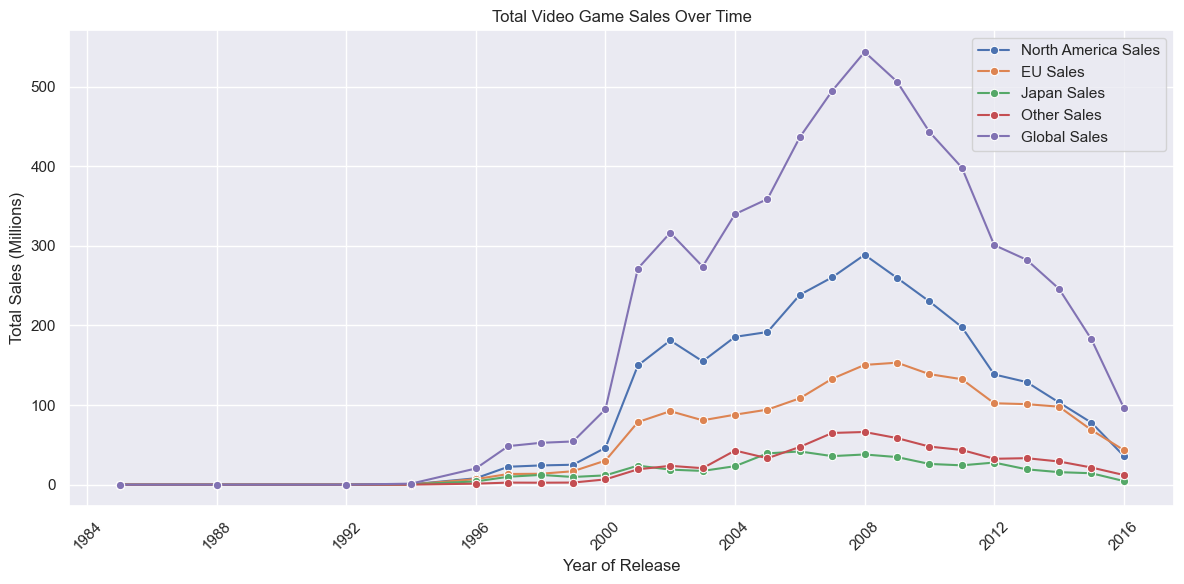

In [17]:
fig = plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year_of_Release", y="NA_Sales", estimator="sum", errorbar=None, marker="o", label="North America Sales")
sns.lineplot(data=df, x="Year_of_Release", y="EU_Sales", estimator="sum", errorbar=None, marker="o", label="EU Sales")
sns.lineplot(data=df, x="Year_of_Release", y="JP_Sales", estimator="sum", errorbar=None, marker="o", label="Japan Sales")
sns.lineplot(data=df, x="Year_of_Release", y="Other_Sales", estimator="sum", errorbar=None, marker="o", label="Other Sales")
sns.lineplot(data=df, x="Year_of_Release", y="Global_Sales", estimator="sum", errorbar=None, marker="o", label="Global Sales")
plt.title("Total Video Game Sales Over Time")
plt.xlabel("Year of Release")
plt.ylabel("Total Sales (Millions)")
plt.xticks(rotation=45)
plt.legend()
fig.tight_layout()
plt.show()
fig.savefig("../figures/sales_over_time.png", dpi=300)


This section creates a line plot showing the total sales of video games over time, broken down by region (`Global_Sales`, `NA_Sales`, `EU_Sales`, `JP_Sales`, and `Other_Sales`). In general, games released between 2006 and 2010 recorded the most sales, with similar trends of growth and decline across all markets. Note that sales are recorded by the release date of each game, so the data may not reflect market trends accurately. The plot is saved as a `.png` file in the `/figures` directory.

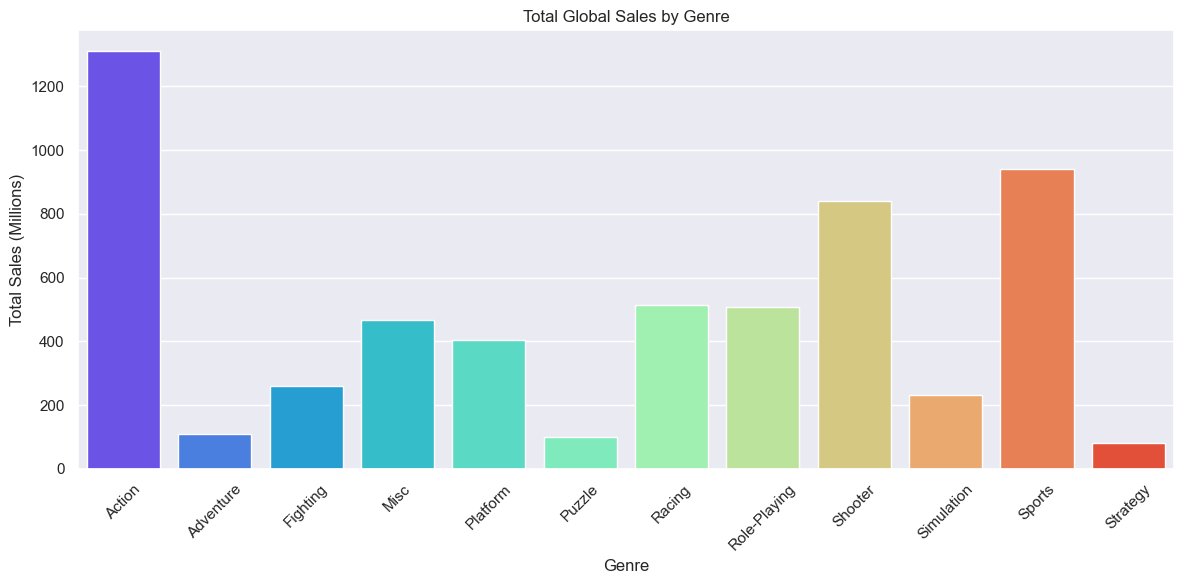

In [18]:
fig = plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Genre", y="Global_Sales", estimator="sum", errorbar=None, palette="rainbow", hue="Genre", dodge=False)
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Sales (Millions)")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()
fig.savefig("../figures/sales_by_genre.png", dpi=300)

This section of code creates a bar plot showing the total global sales of video games by `Genre`. The "Action" genre leads by a substantial margin, being the only genre recording over 1 billion global sales, and is followed by "Sports" and "Shooter". The plot is saved as a `.png` file in the `/figures` directory.

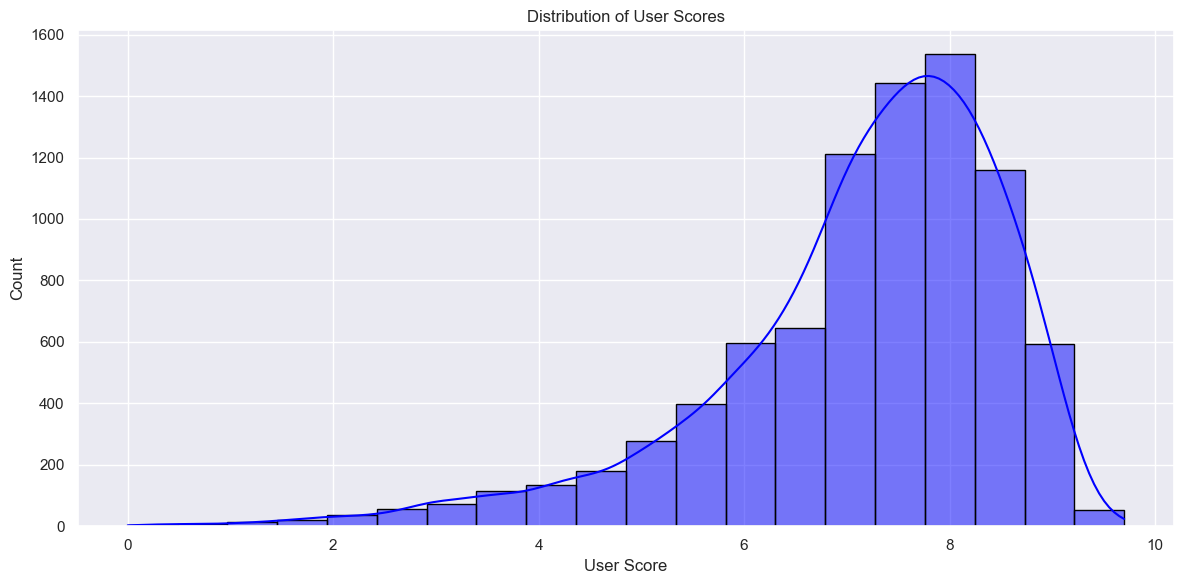

In [19]:
fig = plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="User_Score", bins=20, kde=True, color="blue", edgecolor="black")
plt.title("Distribution of User Scores")
plt.xlabel("User Score")
plt.ylabel("Count")
fig.tight_layout()
plt.show()
fig.savefig("../figures/user_score_distribution.png", dpi=300)

This section creates a histogram plot showing the distribution of user scores for all the video games. The x-axis represents the `User_Score` (ranging from 0 to 10), while the y-axis represents the count of games where the `User_Score` falls in a certain range represented by each bar. The frequency peaks around a `User_Score` of 8 out of 10, meaning that most games are rated positively by users. The plot is saved as a `.png` file in the `/figures` directory.

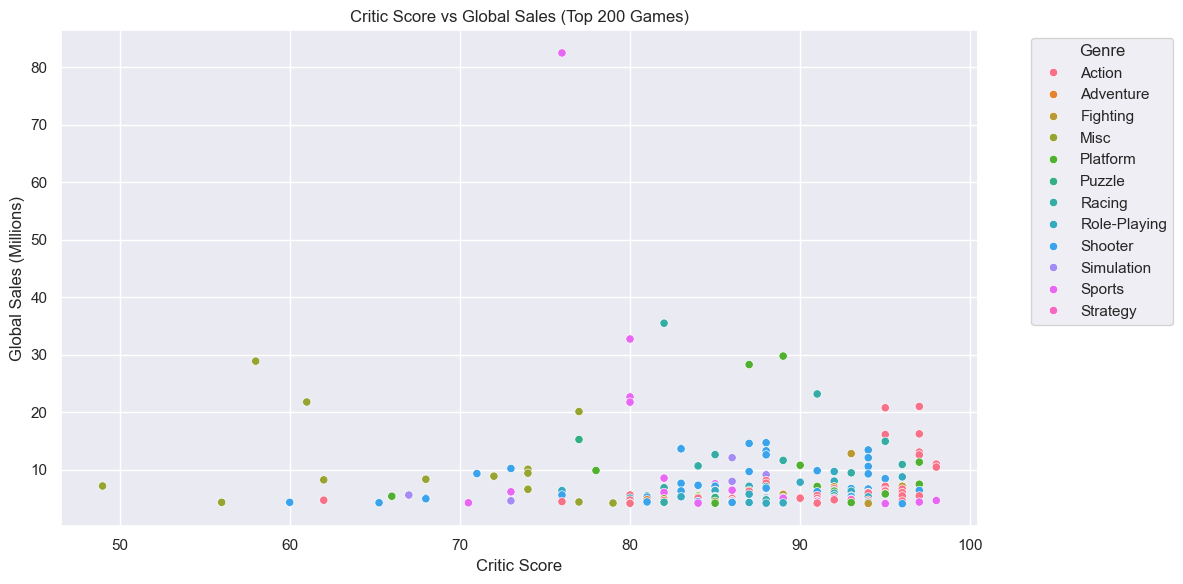

In [20]:
top_sales = df.nlargest(200, "Global_Sales")
fig = plt.figure(figsize=(12, 6))
sns.scatterplot(data=top_sales, x="Critic_Score", y="Global_Sales", hue="Genre", palette="husl")
plt.title("Critic Score vs Global Sales (Top 200 Games)")
plt.xlabel("Critic Score")
plt.ylabel("Global Sales (Millions)")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
plt.show()
fig.savefig("../figures/critic_score_vs_sales.png", dpi=300)

This section creates a scatter plot showing the relationship between `Critic_Score` and `Global_Sales` for the top 200 games by sales, colored by `Genre`. Most of the games shown have a `Critic_Score` of 80 or higher out of 100, implying a positive correlation between critical reception and sales globally, regardless of genre. The plot is saved as a `.png` file in the `/figures` directory.